In [2]:
from matplotlib import pyplot as plt
import numpy as np
import matplotlib as mpl
import re

In [14]:
def data_entry(solver):
    for kmer in ['k501', 'k301', 'k201', 'k101', 'k81', 'sim_k71', 'sim_k61','sim_k51','sim_k41']:
        filename=f'/lustre/scratch127/qpg/jc59/out/oriented/{solver}.ddDapMeze1.MT.{kmer}.utg.final.gfa.compiled.txt'
        try:
            f = open(filename, 'r')
            line = f.readline()
            matches = re.findall(r'\[\d+, \d+.?\d*\]', line)
            matches_array = [[int(x.split(',')[0][1:]), float(x.split(',')[1][0:-1])] for x in matches]
            np.save(f'/lustre/scratch127/qpg/jc59/out/oriented/data.{solver}.{kmer}', matches_array)
        except FileNotFoundError:
            pass

In [15]:
data_entry('mqlib')
data_entry('dwave')
data_entry('gurobi')

In [16]:
dwave_data_k61 = np.load('/lustre/scratch127/qpg/jc59/out/oriented/data.dwave.sim_k61.npy')
dwave_data_k71 = np.load('/lustre/scratch127/qpg/jc59/out/oriented/data.dwave.sim_k71.npy')
dwave_data_k101 = np.load('/lustre/scratch127/qpg/jc59/out/oriented/data.dwave.k101.npy')
# dwave_data_k201 = np.load('/lustre/scratch127/qpg/jc59/out/oriented/data.dwave.k201.npy')
dwave_data_k301 = np.load('/lustre/scratch127/qpg/jc59/out/oriented/data.dwave.k301.npy')
dwave_data_k501 = np.load('/lustre/scratch127/qpg/jc59/out/oriented/data.dwave.k501.npy')


mqlib_data_k41 = np.load('/lustre/scratch127/qpg/jc59/out/oriented/data.mqlib.sim_k41.npy')
mqlib_data_k51 = np.load('/lustre/scratch127/qpg/jc59/out/oriented/data.mqlib.sim_k51.npy')
mqlib_data_k61 = np.load('/lustre/scratch127/qpg/jc59/out/oriented/data.mqlib.sim_k61.npy')
mqlib_data_k71 = np.load('/lustre/scratch127/qpg/jc59/out/oriented/data.mqlib.sim_k71.npy')
mqlib_data_k101 = np.load('/lustre/scratch127/qpg/jc59/out/oriented/data.mqlib.k101.npy')
# mqlib_data_k201 = np.load('/lustre/scratch127/qpg/jc59/out/oriented/data.mqlib.k201.npy')
mqlib_data_k301 = np.load('/lustre/scratch127/qpg/jc59/out/oriented/data.mqlib.k301.npy')
mqlib_data_k501 = np.load('/lustre/scratch127/qpg/jc59/out/oriented/data.mqlib.k501.npy')

gurobi_data_k41 = np.load('/lustre/scratch127/qpg/jc59/out/oriented/data.gurobi.sim_k41.npy')
gurobi_data_k51 = np.load('/lustre/scratch127/qpg/jc59/out/oriented/data.gurobi.sim_k51.npy')
gurobi_data_k61 = np.load('/lustre/scratch127/qpg/jc59/out/oriented/data.gurobi.sim_k61.npy')
gurobi_data_k71 = np.load('/lustre/scratch127/qpg/jc59/out/oriented/data.gurobi.sim_k71.npy')
gurobi_data_k101 = np.load('/lustre/scratch127/qpg/jc59/out/oriented/data.gurobi.k101.npy')
# gurobi_data_k201 = np.load('/lustre/scratch127/qpg/jc59/out/oriented/data.gurobi.k201.npy')
gurobi_data_k301 = np.load('/lustre/scratch127/qpg/jc59/out/oriented/data.gurobi.k301.npy')
gurobi_data_k501 = np.load('/lustre/scratch127/qpg/jc59/out/oriented/data.gurobi.k501.npy')

In [13]:
times, counts = np.unique(mqlib_data_k61[:,0], return_counts=True)
print(times, counts)

[ 15.  30.  60. 120. 240.] [5 5 5 5 5]


In [15]:
data, counts = np.unique(gurobi_data_k41[:, 1], return_counts=True)
print(data, counts)

[13. 15. 19. 20. 21. 23.] [7 1 1 3 2 1]


In [16]:
def compare_solvers(*args):
    fig, ax = plt.subplots()
    
    cmap = mpl.colormaps['magma_r']
    
    colours = cmap(np.linspace(0.1, 0.9, len(args)))
    names = ['D-Wave', 'Gurobi', 'MQLib']
    markers = ['o', 'x', 's', 'v']
    
    for idx, data in enumerate(args):
        unique_data, unique_counts = np.unique(data, return_counts=True, axis=0)
        # times, time_counts = np.unique(data[:, 0], return_counts=True)
        marker_sizes = np.zeros_like(unique_data[:, 0])
        for i in range(unique_counts.shape[0]):
            # marker_sizes[i] = 10 ** 2 * (unique_counts[i] / time_counts[np.argmax(times == unique_data[i, 0])])
            marker_sizes[i] = 5 ** 2 * (unique_counts[i])
        ax.scatter(unique_data[:, 0] / 60, unique_data[:, 1], s=marker_sizes, color=colours[idx], label=names[idx], alpha=0.5, marker=markers[idx])
        
    ax.set_xlabel(r'$T / 60$')
    ax.set_ylabel(r'Energy')
    ax.set_xscale('log', base=2)
    # ax.set_yscale('log')
    ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.5))
    ax.grid(True, which="both")
    fig.tight_layout()
    plt.show()

In [17]:
def compare_problem_sizes(*args):
    fig, ax = plt.subplots()
    
    cmap = mpl.colormaps['magma_r']

    # Take colors at regular intervals spanning the colormap.
    colours = cmap(np.linspace(0.1, 0.9, len(args)))
    
    markers = ['o', 'x', 's', 'v']
    
    kmer_sizes = [arg[0] for arg in args]
    
    for idx, data in enumerate(args):
        unique_data, unique_counts = np.unique(data[1], return_counts=True, axis=0)
        # times, time_counts = np.unique(data[:, 0], return_counts=True)
        marker_sizes = np.zeros_like(unique_data[:, 0])
        for i in range(unique_counts.shape[0]):
            # marker_sizes[i] = 10 ** 2 * (unique_counts[i] / time_counts[np.argmax(times == unique_data[i, 0])])
            marker_sizes[i] = 5 ** 2 * (unique_counts[i])
        ax.scatter(
            np.round(unique_data[:, 0] / 60, 1), unique_data[:, 1], 
            s=marker_sizes, color=colours[idx], label=kmer_sizes[idx], alpha=0.5, marker=markers[idx]
        )
    
    ax.set_xlabel(r'$T / 60$')
    ax.set_ylabel(r'Energy')
    ax.set_xscale('log', base=2)
    # ax.set_yscale('log')
    ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), title='k')
    ax.grid(True, which="both")
    fig.tight_layout()
    plt.show()

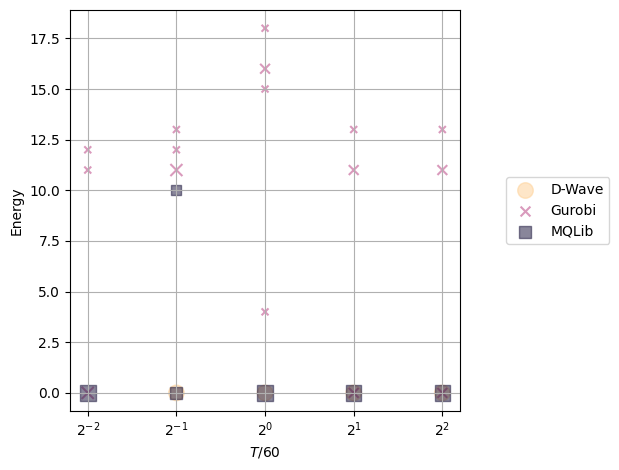

In [18]:
compare_solvers(dwave_data_k101, gurobi_data_k101, mqlib_data_k101)

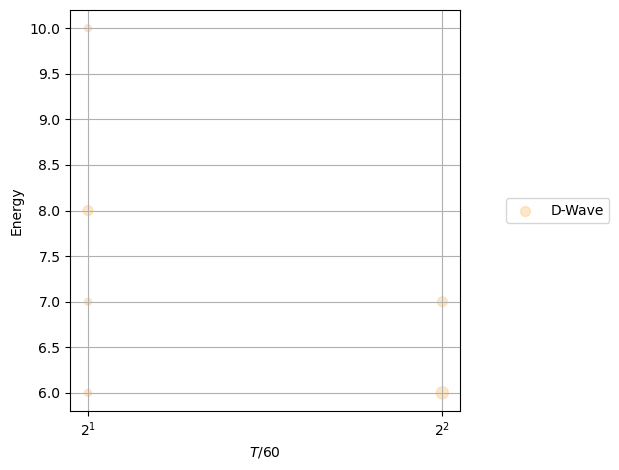

In [30]:
compare_solvers(dwave_data_k101)

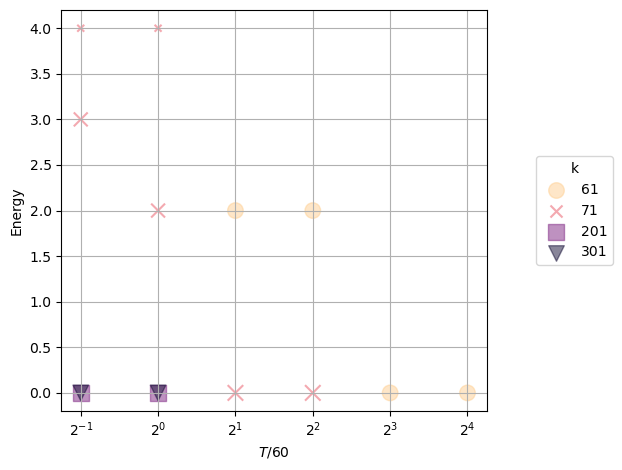

In [27]:
compare_problem_sizes(
    (61, mqlib_data_k61), 
    (71, mqlib_data_k71), 
    (201, mqlib_data_k201),
    (301, mqlib_data_k201),
)

In [11]:
def solver_histograms(title: str, data_tuple: tuple):
    all_times = set()
    for data in data_tuple:
        all_times = all_times.union(set(data[:, 0]))
    all_times = sorted(list(all_times))
    
    all_energies = set()
    for data in data_tuple:
        all_energies = all_energies.union(set(data[:, 1]))
    all_energies = sorted(list(all_energies))
    
    bins = np.arange(min(all_energies), max(all_energies) + 2)
    
    names = ['MQLib', 'Gurobi', 'D-Wave']
     
    fig, axs = plt.subplots(nrows=1, ncols=len(all_times), sharex=True)
    fig.subplots_adjust(left=-1, right=0)
    
    for idx, time in enumerate(all_times):
        energies = [data[data[:, 0] == time][:, 1] for data in data_tuple]
        ax = axs[idx]
        ax.hist(energies, bins, orientation='horizontal', align='left', rwidth=0.4)
        ax.set_xlabel(fr'$T = {int(time)}$')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.get_xaxis().set_ticks([])
        if not idx == 0:
            ax.get_yaxis().set_ticks([])
            # ax.spines['left'].set_visible(False)
     
    axs[0].set_ylabel(r'Energy')
    fig.legend(names, loc='center left', bbox_to_anchor=(1., 0.5), title='k')
    fig.tight_layout()
    st = plt.suptitle(title)
    st.set_y(0.95)
    fig.subplots_adjust(top=0.85)   
    plt.show()

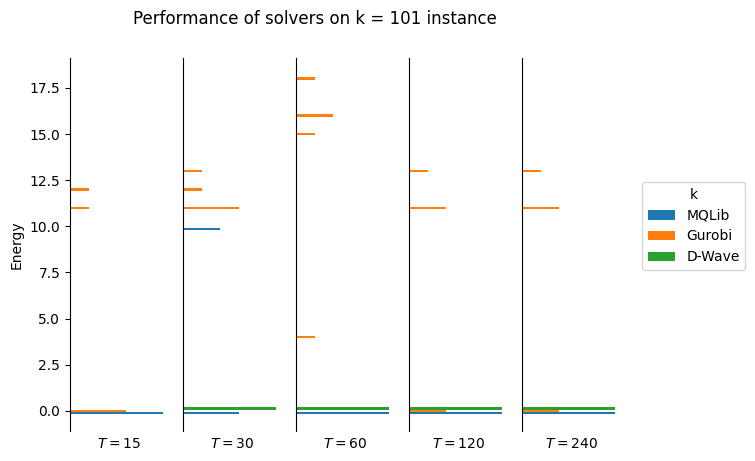

In [20]:
solver_histograms(
    'Performance of solvers on k = 101 instance', 
    (mqlib_data_k101, gurobi_data_k101, dwave_data_k101)
)

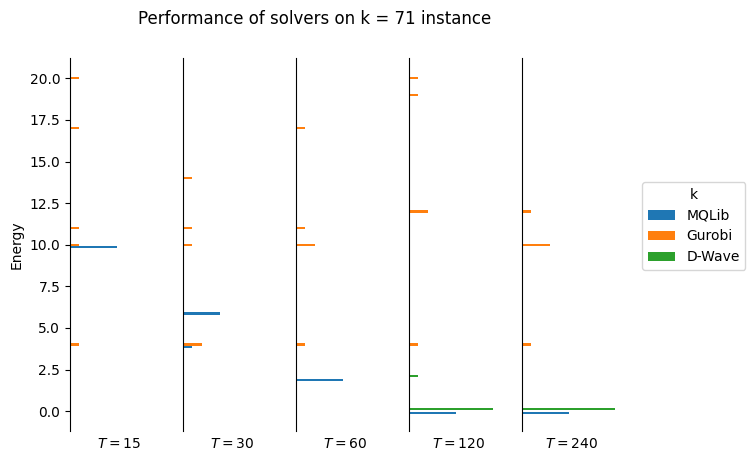

In [23]:
solver_histograms(
    'Performance of solvers on k = 71 instance', 
    (mqlib_data_k71, gurobi_data_k71, dwave_data_k71)
)

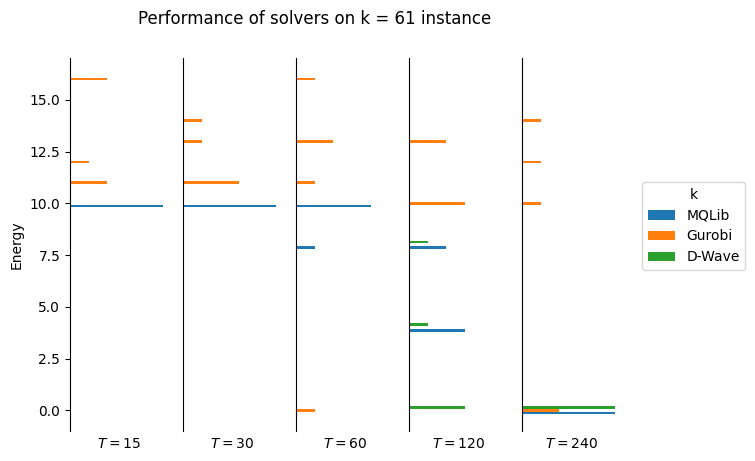

In [17]:
solver_histograms(
    'Performance of solvers on k = 61 instance', 
    (mqlib_data_k61, gurobi_data_k61, dwave_data_k61)
)

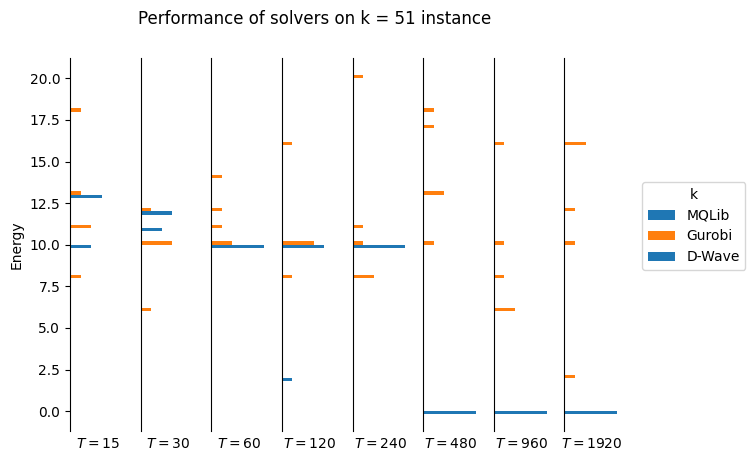

In [18]:
solver_histograms(
    'Performance of solvers on k = 51 instance', 
    (mqlib_data_k51, gurobi_data_k51)
)

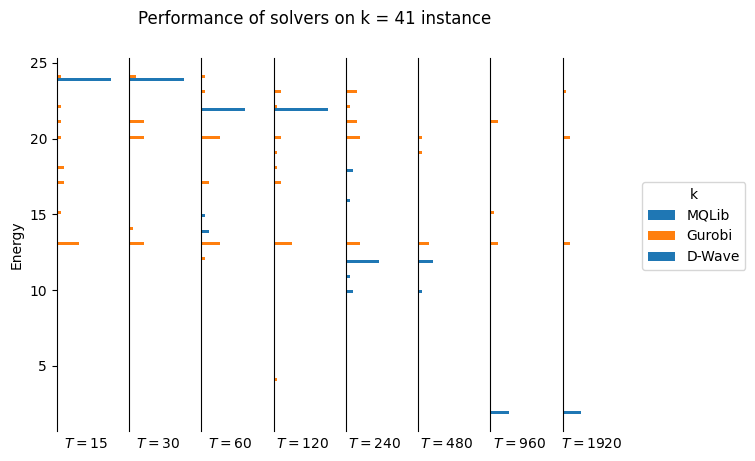

In [29]:
solver_histograms(
    'Performance of solvers on k = 41 instance', 
    (mqlib_data_k41, gurobi_data_k41)
)